In [6]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load Raw Data    
df = pd.read_csv("retrospective_raw_data.csv")
df.head()

df = df.drop(columns=['DomesticForeign', 'District'])
df['HS_Code'] = df['Commodities'].astype(str).str[:4]

years = df[df['Time'].astype(str).str.strip().str.len() == 4]
years = df['Time']

# Remove rows with only year because all monthly values add up to the yearly value anyway
df = df[df['Time'].astype(str).str.strip().str.len() != 4]

# Create Month column
temp = df['Time'].str.split()
month_map = {
    "January": 1,
    "February": 2,
    "March": 3,
    "April": 4,
    "May": 5,
    "June": 6,
    "July": 7,
    "August": 8,
    "September": 9,
    "October": 10,
    "November": 11,
    "December": 12
}

df['Month'] = temp.str[0].map(month_map)

# Create Year column
df['Year'] = temp.str[-1].astype(int)
df = df.drop(columns = ['Time'])






,Commodities,Countries,Value ($US) (Default Member),HS_Code,Month,Year
16,2504 Natural Graphite,Canada,114438,2504,1,2010
17,2504 Natural Graphite,Canada,25604,2504,2,2010
18,2504 Natural Graphite,Canada,26688,2504,3,2010
19,2504 Natural Graphite,Canada,28806,2504,4,2010
20,2504 Natural Graphite,Canada,31919,2504,5,2010


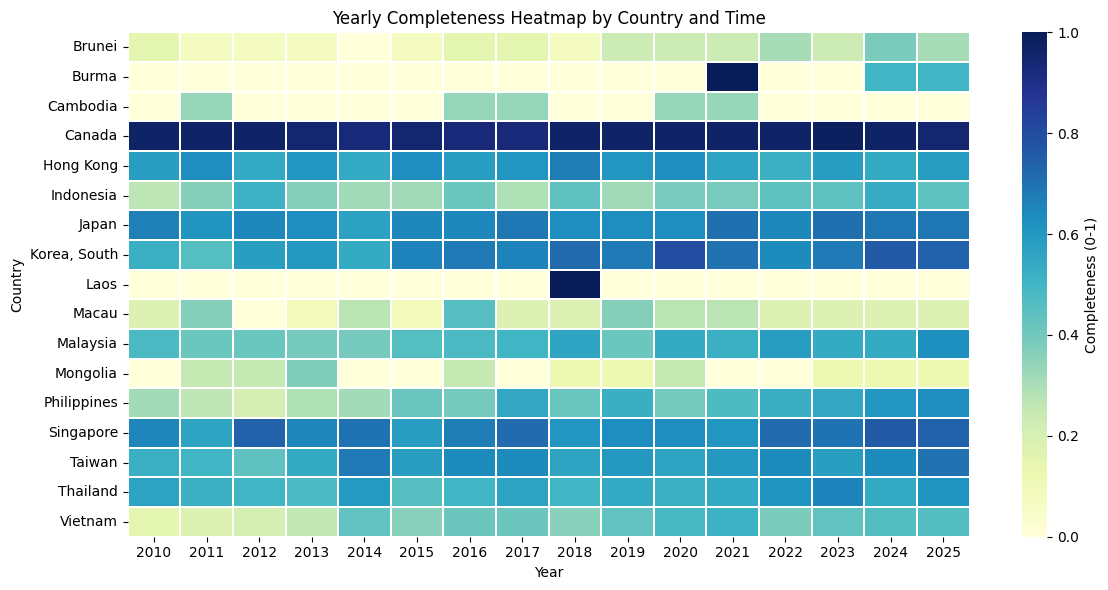

In [2]:
country_col = "Countries" if "Countries" in df.columns else None
commodity_col = "Commodities" if "Commodities" in df.columns else None
if country_col is None or commodity_col is None:
    raise ValueError("Missing Countries or Commodities column. Please check the raw data schema.")

# filter yearly data
yearly = df[df["Time"].astype(str).str.fullmatch(r"\d{4}", na=False)].copy()
yearly["year"] = pd.to_numeric(yearly["Time"], errors="coerce").astype("Int64")
yearly_plot = yearly.dropna(subset=["year"]).copy()
yearly_plot["year"] = yearly_plot["year"].astype(int)

# observed commodities per country-year
observed = yearly_plot.groupby([country_col, "year"])[commodity_col].nunique()

# total number of commodities per country over all years
total = yearly_plot.groupby(country_col)[commodity_col].nunique()

completeness = observed.div(total, level=0).rename("completeness")

# matrix for heatmap
yearly_pivot = (
    completeness.reset_index()
    .pivot(index=country_col, columns="year", values="completeness")
    .fillna(0)
    .sort_index()
    .sort_index(axis=1)
)

n_rows, n_cols = yearly_pivot.shape
fig_w = max(12, min(36, n_cols * 0.28))
fig_h = max(6, min(30, n_rows * 0.35))

plt.figure(figsize=(fig_w, fig_h))
sns.heatmap(
    yearly_pivot,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.2,
    linecolor="white",
    cbar_kws={"label": "Completeness (0-1)"}
 )
plt.title("Yearly Completeness Heatmap by Country and Time")
plt.xlabel("Year")
plt.ylabel("Country")
plt.tight_layout()
plt.show()